In [2]:
import pandas as pd
import json

In [3]:
# Load the batch response JSONL file and extract custom_id and response message content
batch_answerable = []
with open('batch/batch_68c2e547b8ec8190b9160922db55bb45_output.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        batch_answerable.append({
            'id': data.get('custom_id'),
            'llm_label': data.get('response').get('body').get('choices')[0].get('message').get('content')
        })

batch_df = pd.DataFrame(batch_answerable)

batch_df['llm_label'] = batch_df['llm_label'].str.replace(r".*true.*", "True", case=False, regex=True)
batch_df['llm_label'] = batch_df['llm_label'].str.replace(r".*false.*", "False", case=False, regex=True)

batch_df['llm_label'].unique()

array(['False', 'True'], dtype=object)

In [5]:
# Load the batch response JSONL file and extract custom_id and response message content
response_answerable = []
with open('batch/responses_answerable_sample_20250914_140527.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        res = json.loads(data.get('response').replace('```json', '').replace('```', ''))
        response_answerable.append({
            'id': data.get('custom_id'),
            'llm_label': res['answerable'],
            'llm_reason': res['reason']
        })

response_df = pd.DataFrame(response_answerable)

response_df['llm_label'].unique()

array([False,  True])

In [6]:
llm_df = response_df

In [7]:
manual_df = pd.read_csv('batch/questions_manually_labelled.csv')
df = manual_df.merge(llm_df, on='id', how='outer')

df.head()

,id,question,manual_label,llm_label,llm_reason
0,0203b828-6d87-4401-a595-2641e724a84a,When bleeding doesn't stop on applying pressur...,True,True,The question can be answered based on medical ...
1,023d8cff-cf4b-4485-82d6-0e3383c0a232,A 65-year old man presented with skin lesions ...,True,True,The question asks about the cause of a conditi...
2,03fc9796-972f-4ae6-8ebd-f86fcd7fed1f,Which of the following human malignancy is hig...,False,False,Question explicitly references options with 'W...
3,045f9534-2b60-4d2a-8eab-679494476682,A 65-year-old man with a long history of diabe...,True,True,The question asks for the likely pathogen base...
4,04f63c22-157d-4d25-bdae-2ffc1b0b57c2,Cat bites in child treatment - false is,False,False,Question explicitly references options.


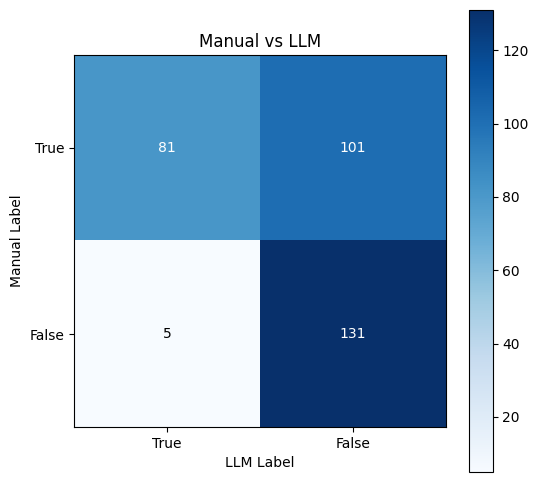

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = [True, False]
cm = confusion_matrix(df['manual_label'], df['llm_label'], labels=labels)

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Manual vs LLM')
plt.xlabel('LLM Label')
plt.ylabel('Manual Label')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.colorbar()

# Annotate each cell with the numeric value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.show()


In [9]:
df[(df['manual_label'] == False) & (df['llm_label'] == True)].to_csv('batch/question_fp.csv', index=False)
df[(df['manual_label'] == True) & (df['llm_label'] == False)].to_csv('batch/question_fn.csv', index=False)
df.to_csv('batch/question_all.csv', index=False)